# Fashion-MNIST

Competition-ready pipeline: reproducible setup, train/validation split, robust model training, and submission export.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)
print('TensorFlow version:', tf.__version__)

2026-03-31 11:12:17.660287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0


In [ ]:
DATA_DIR = '/kaggle/input/fashion-mnist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = './data'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'fashion-mnist_train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'fashion-mnist_test.csv'))

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
display(train_df.head())

Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print('Missing values in train:', int(train_df.isna().sum().sum()))
print('Missing values in test :', int(test_df.isna().sum().sum()))

label_names = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}
display(train_df['label'].value_counts().sort_index().rename(index=label_names))

Missing values in train: 0
Missing values in test : 0


label
T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
Name: count, dtype: int64

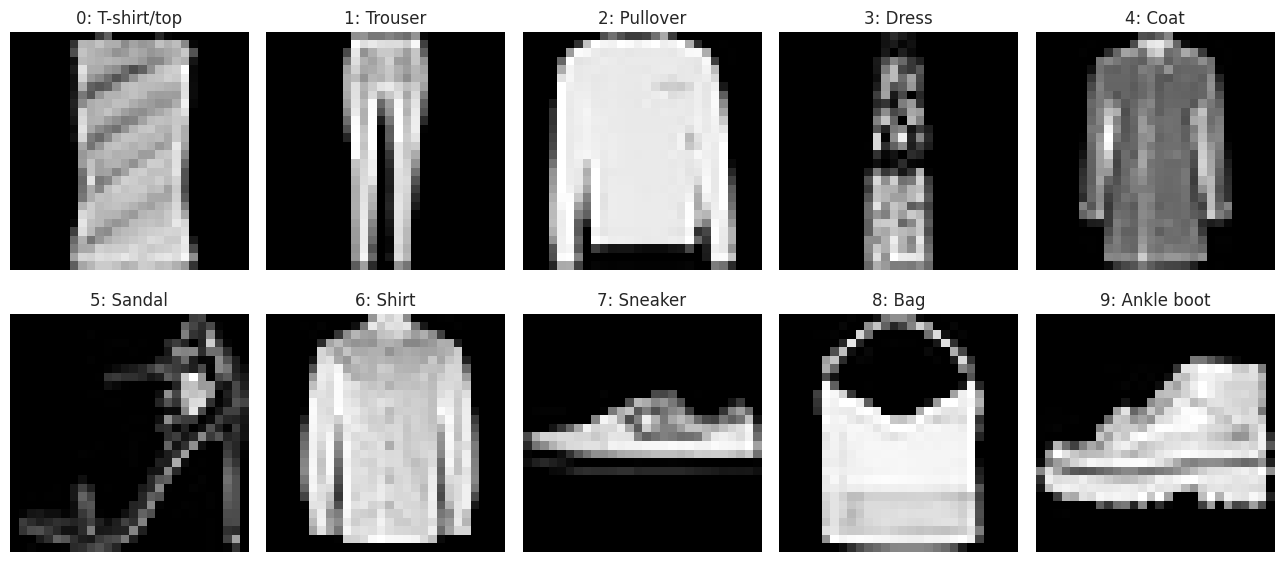

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for cls in range(10):
    ax = axes[cls // 5, cls % 5]
    row = train_df[train_df['label'] == cls].sample(1, random_state=42)
    img = row.drop(columns=['label']).to_numpy().reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{cls}: {label_names[cls]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
X = train_df.drop(columns=['label']).to_numpy(dtype='float32') / 255.0
y = train_df['label'].to_numpy(dtype='int64')
X = X.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

test_has_label = 'label' in test_df.columns
X_test = test_df.drop(columns=['label'], errors='ignore').to_numpy(dtype='float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
if test_has_label:
    y_test_true = test_df['label'].to_numpy(dtype='int64')

print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)

X_train: (51000, 28, 28, 1) X_val: (9000, 28, 28, 1) X_test: (10000, 28, 28, 1)


In [5]:
BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices(X_test).batch(BATCH_SIZE).prefetch(AUTOTUNE)

2026-03-28 15:06:43.433749: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-03-28 15:06:43.436533: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 159936000 exceeds 10% of free system memory.


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.40),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    tf.keras.callbacks.ModelCheckpoint('best_fashion_mnist.keras', monitor='val_accuracy', save_best_only=True)
]

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,258 (6.49 MB)

 Trainable params: 1,701,194 (6.49 MB)

 Non-trainable params: 64 (256.00 B)

In [7]:
history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks, verbose=1)

Epoch 1/25


2026-03-28 15:08:12.632014: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 159936000 exceeds 10% of free system memory.


200/200 ━━━━━━━━━━━━━━━━━━━━ 122s 599ms/step - accuracy: 0.7922 - loss: 0.5897 - val_accuracy: 0.8640 - val_loss: 1.6924 - learning_rate: 0.0010
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 118s 592ms/step - accuracy: 0.8797 - loss: 0.3286 - val_accuracy: 0.8969 - val_loss: 0.7226 - learning_rate: 0.0010
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 125s 624ms/step - accuracy: 0.8987 - loss: 0.2784 - val_accuracy: 0.9106 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 126s 628ms/step - accuracy: 0.9098 - loss: 0.2465 - val_accuracy: 0.9178 - val_loss: 0.2204 - learning_rate: 0.0010
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 123s 617ms/step - accuracy: 0.9165 - loss: 0.2266 - val_accuracy: 0.9232 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 730ms/step - accuracy: 0.9232 - loss: 0.2083 - val_accuracy: 0.9240 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 729ms/step - accuracy: 0.9276 

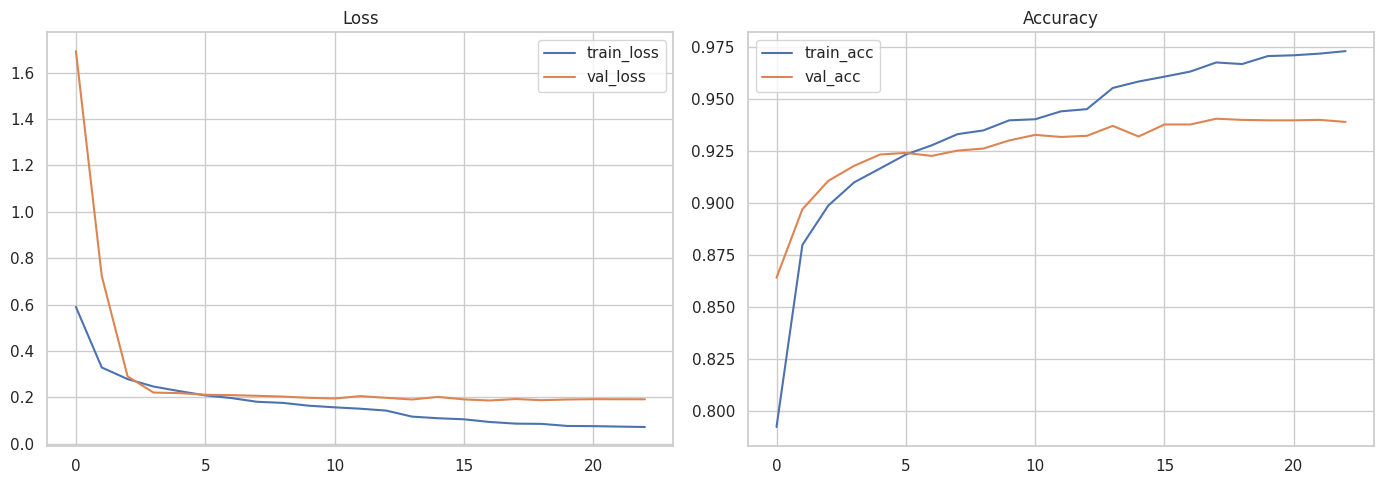

In [8]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist['loss'], label='train_loss')
axes[0].plot(hist['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(hist['accuracy'], label='train_acc')
axes[1].plot(hist['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

Validation loss: 0.1925
Validation accuracy: 0.9404
              precision    recall  f1-score   support

           0     0.8689    0.9056    0.8868       900
           1     0.9922    0.9956    0.9939       900
           2     0.9333    0.9022    0.9175       900
           3     0.9412    0.9433    0.9423       900
           4     0.8960    0.9189    0.9073       900
           5     0.9878    0.9889    0.9883       900
           6     0.8452    0.8189    0.8318       900
           7     0.9679    0.9722    0.9701       900
           8     0.9955    0.9900    0.9928       900
           9     0.9776    0.9689    0.9732       900

    accuracy                         0.9404      9000
   macro avg     0.9406    0.9404    0.9404      9000
weighted avg     0.9406    0.9404    0.9404      9000



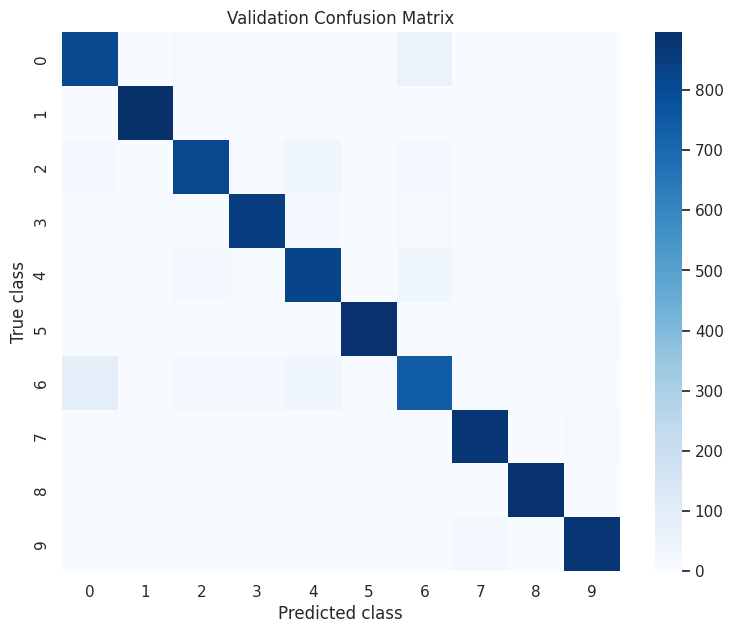

In [9]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f'Validation loss: {val_loss:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')

val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
print(classification_report(y_val, val_pred, digits=4))

cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.show()

In [10]:
test_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
if test_has_label:
    holdout_acc = (test_pred == y_test_true).mean()
    print(f'Provided test-label accuracy: {holdout_acc:.4f}')

if 'id' in test_df.columns:
    submission = pd.DataFrame({'id': test_df['id'], 'label': test_pred})
elif 'ImageId' in test_df.columns:
    submission = pd.DataFrame({'ImageId': test_df['ImageId'], 'Label': test_pred})
else:
    submission = pd.DataFrame({'ImageId': np.arange(1, len(test_pred) + 1), 'Label': test_pred})

submission.to_csv('submission.csv', index=False)
model.save('fashion_mnist_cnn.keras')
display(submission.head())
print('Saved: submission.csv and fashion_mnist_cnn.keras')

Provided test-label accuracy: 0.9435


,ImageId,Label
0,1,0
1,2,1
2,3,2
3,4,2
4,5,3


Saved: submission.csv and fashion_mnist_cnn.keras
